In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-18 12:29:01.023925


# Broad cell labels

* whole cell, no transgenes branch > Model B

In [2]:
import os
from pathlib import Path
import scanpy as sc
from scipy.sparse import issparse
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import warnings
import session_info
import sys

In [3]:
plt.rcParams['figure.figsize'] = (3, 3)
#plt.rcParams['figure.dpi'] = 300

In [4]:
base_dir = Path('/home/workspace/projects/drg')

base_dir = Path("/home/workspace/projects/drg")
input_dir = base_dir / "data/h5ad/export_02/03_annotated"
output_dir = base_dir / "data/h5ad/export_03/01_broad-labels"

output_dir.mkdir(parents=True, exist_ok=True)
#fig_dir.mkdir(parents=True, exist_ok=True)

## Read data

In [5]:
adata = sc.read_h5ad(os.path.join(input_dir, 'ModelB_whole_noTG_annotated.h5ad'))
adata

AnnData object with n_obs × n_vars = 97027 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nuclear_fraction', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'scvi_model', 'leiden_scVI_1'
    var: 'Ensembl ID', 'Probesets', 'zhen_list', 'spectral_panel', 'neurons_supervised', 'neurons_unsupervised', 'glia_supervised', 'glia_unsupervised', 'other', 'neuron_DEGs', 'neuron_detection_rate', 'glia_detection_rate', 'combined_detection_rate_mean'
    uns: '_scvi_manager_uuid', '_scvi_uuid',

# Marker genes

### Run DE rankings on clusters

In [6]:
# performance warning here but should be fine

sc.tl.rank_genes_groups(adata, groupby='leiden_scVI_1', method='wilcoxon')
df = sc.get.rank_genes_groups_df(adata, group = None)
df = df.copy()
df = df[(df.pvals_adj < 0.05) & (df.logfoldchanges > .5)].copy()
df.head(5)

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:429: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,Mbp,174.226257,6.869099,0.0,0.0
1,0,Prx,173.532639,10.253063,0.0,0.0
2,0,Cldn19,168.275253,10.719274,0.0,0.0
3,0,Ugt8a,159.786270,9.278867,0.0,0.0
4,0,Pllp,158.501923,9.747287,0.0,0.0


In [7]:
#clusters_path = os.path.join(clusters_dir, 'rank-genes-clusters.csv')

#df.to_csv(clusters_path, index=False)
#print(clusters_path)

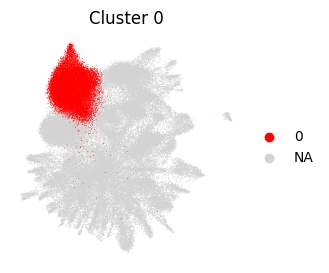

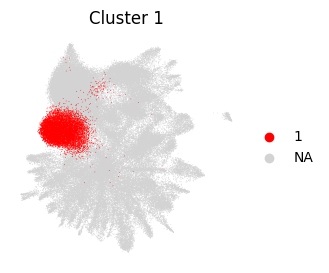

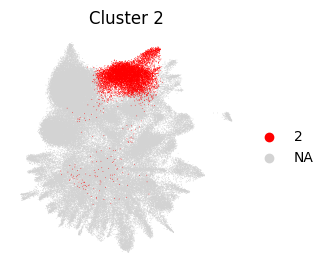

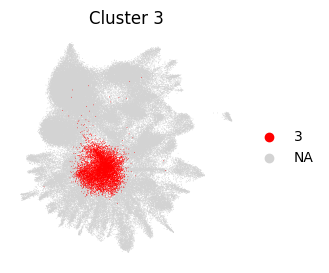

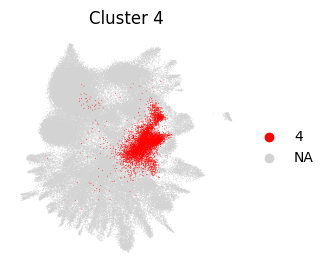

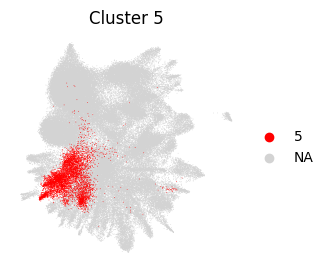

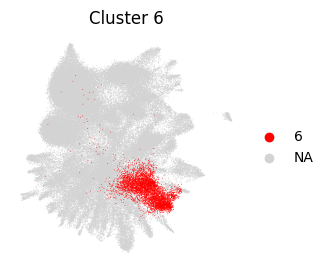

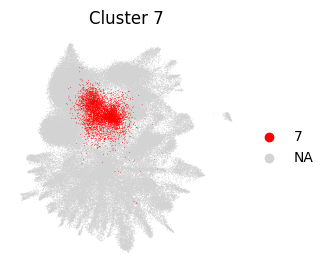

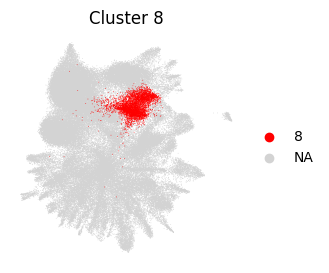

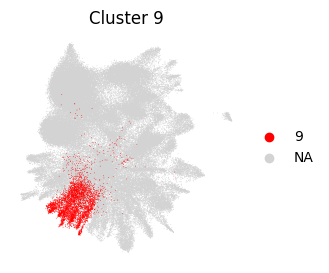

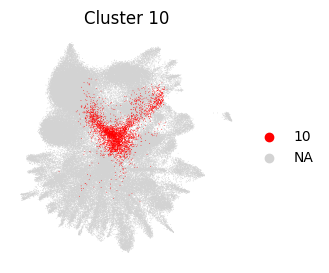

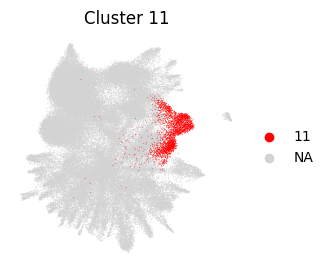

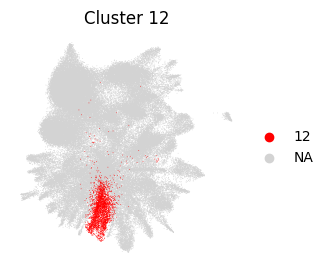

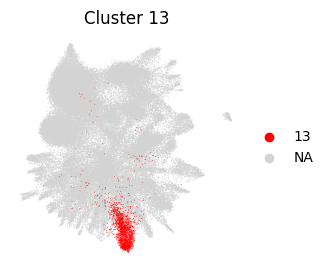

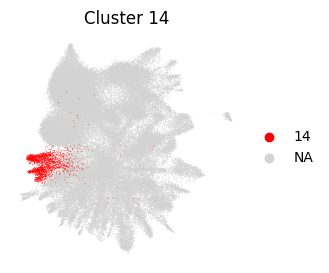

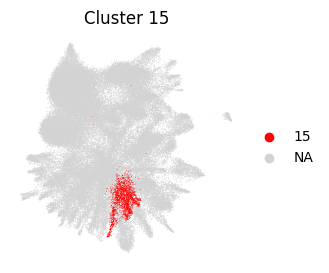

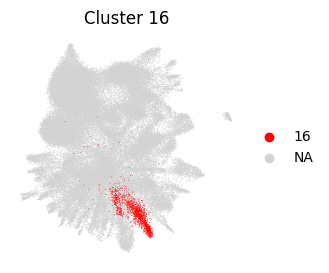

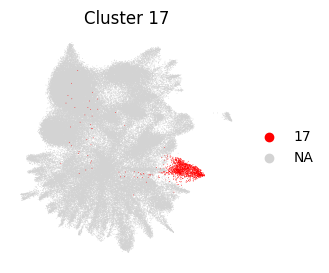

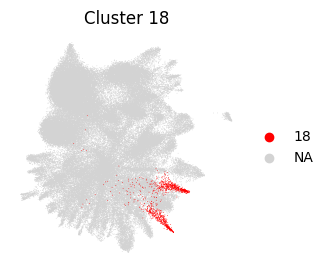

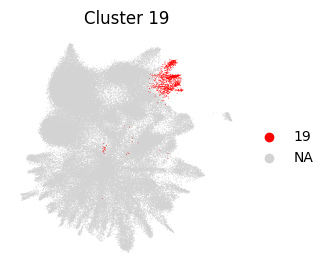

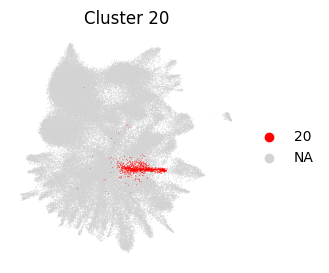

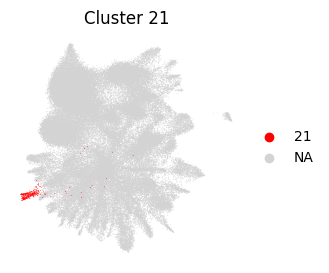

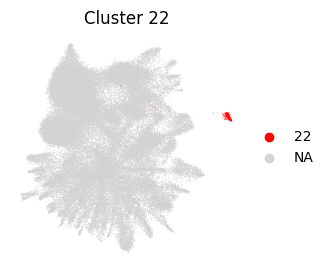

In [8]:
bdata = adata.copy()
for cl in bdata.obs['leiden_scVI_1'].cat.categories:
    sc.pl.umap(
        bdata,
        color='leiden_scVI_1',
        groups=[cl],
        palette=['red'],    
        title=f"Cluster {cl}",
        frameon=False,
        show=True,
    )

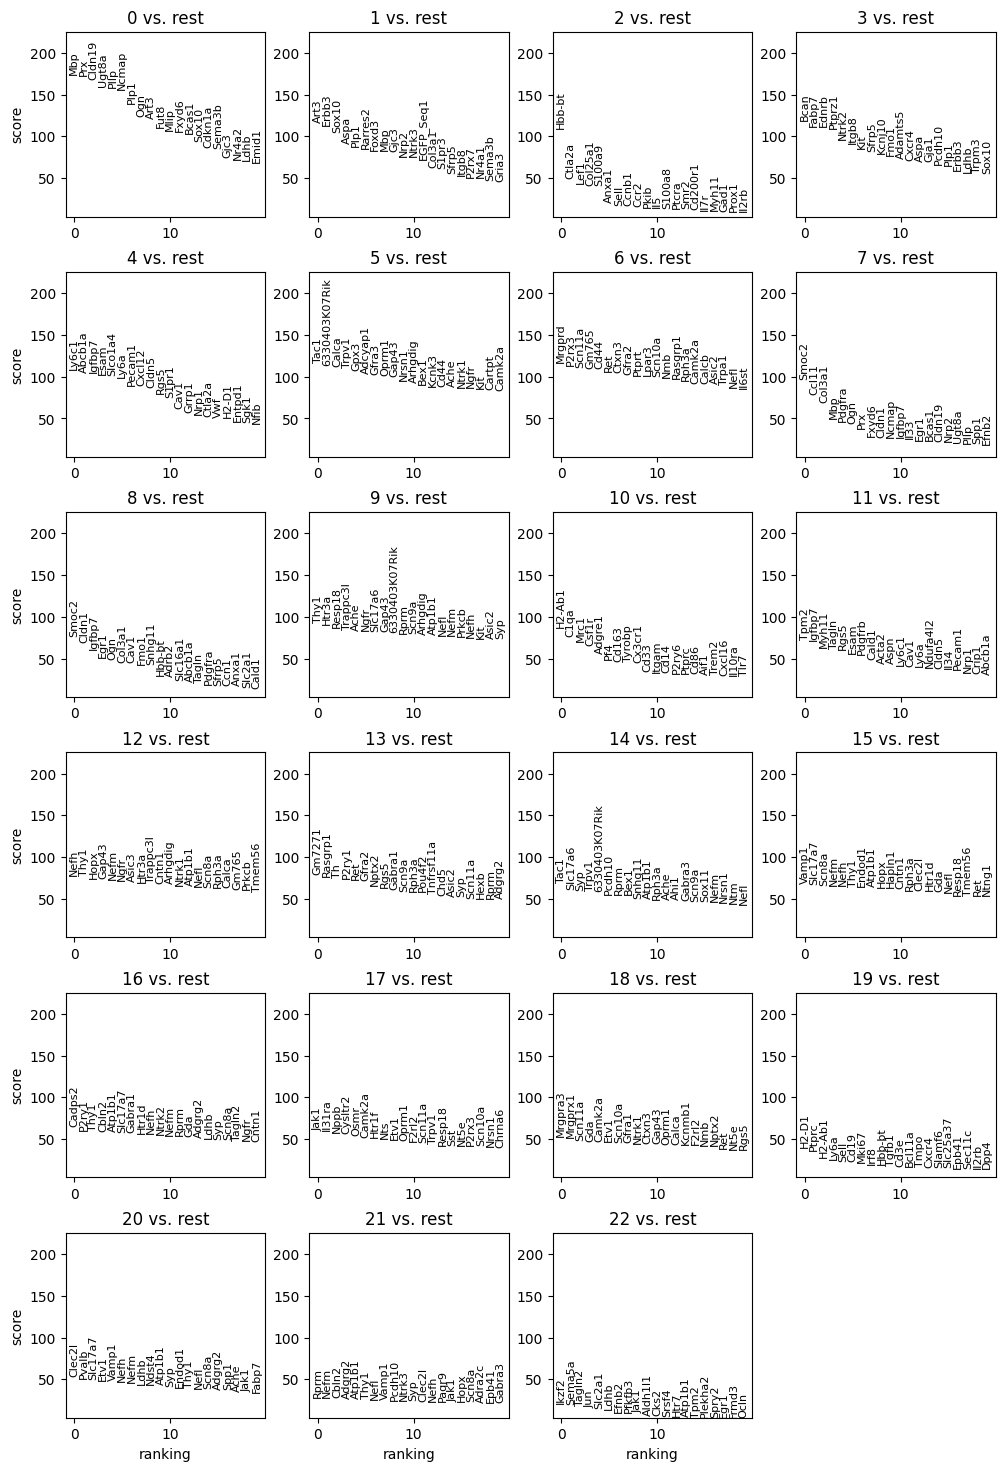

In [9]:
# Visualize top results
sc.pl.rank_genes_groups(adata, groupby = 'leiden_scVI_1', method = 'wilcoxon')

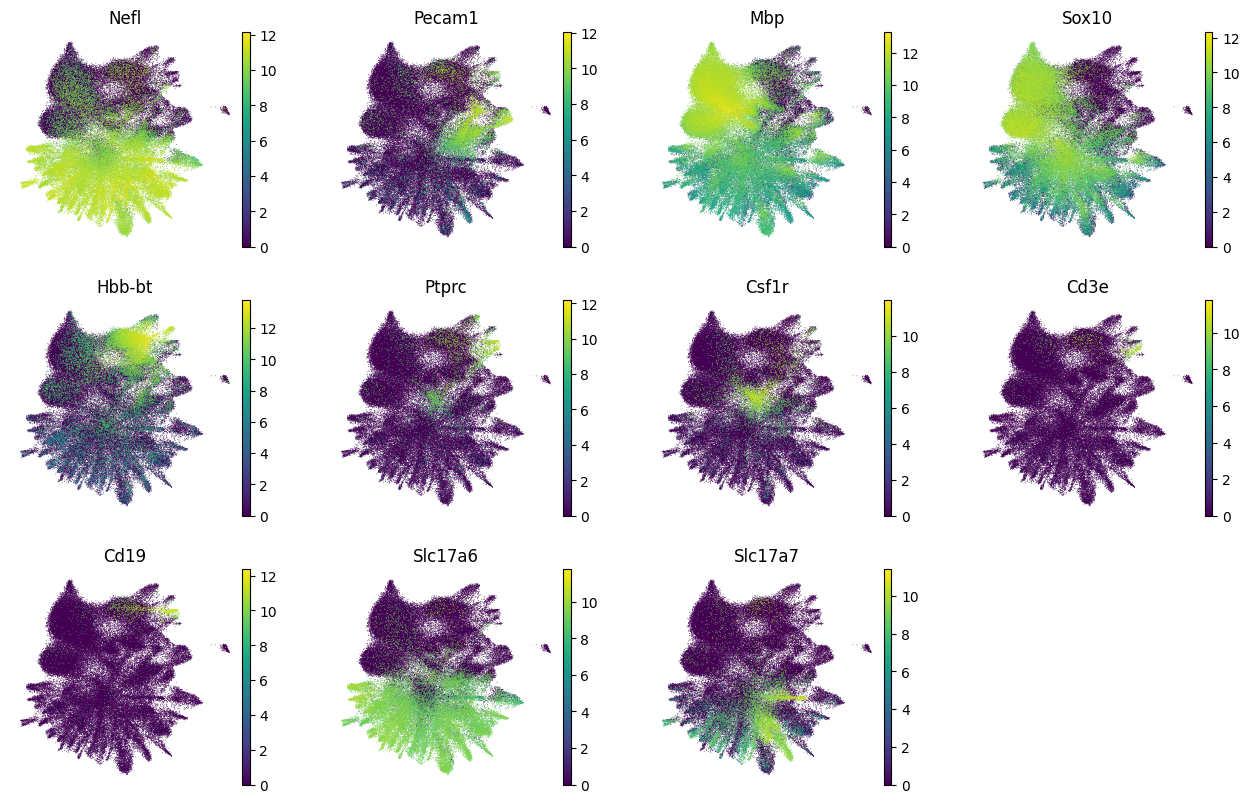

In [10]:
sc.pl.umap(adata, color = ['Nefl', 'Pecam1', 'Mbp', 'Sox10', 'Hbb-bt', 'Ptprc', 'Csf1r', 'Cd3e', 'Cd19', 'Slc17a6', 'Slc17a7'], frameon = False)


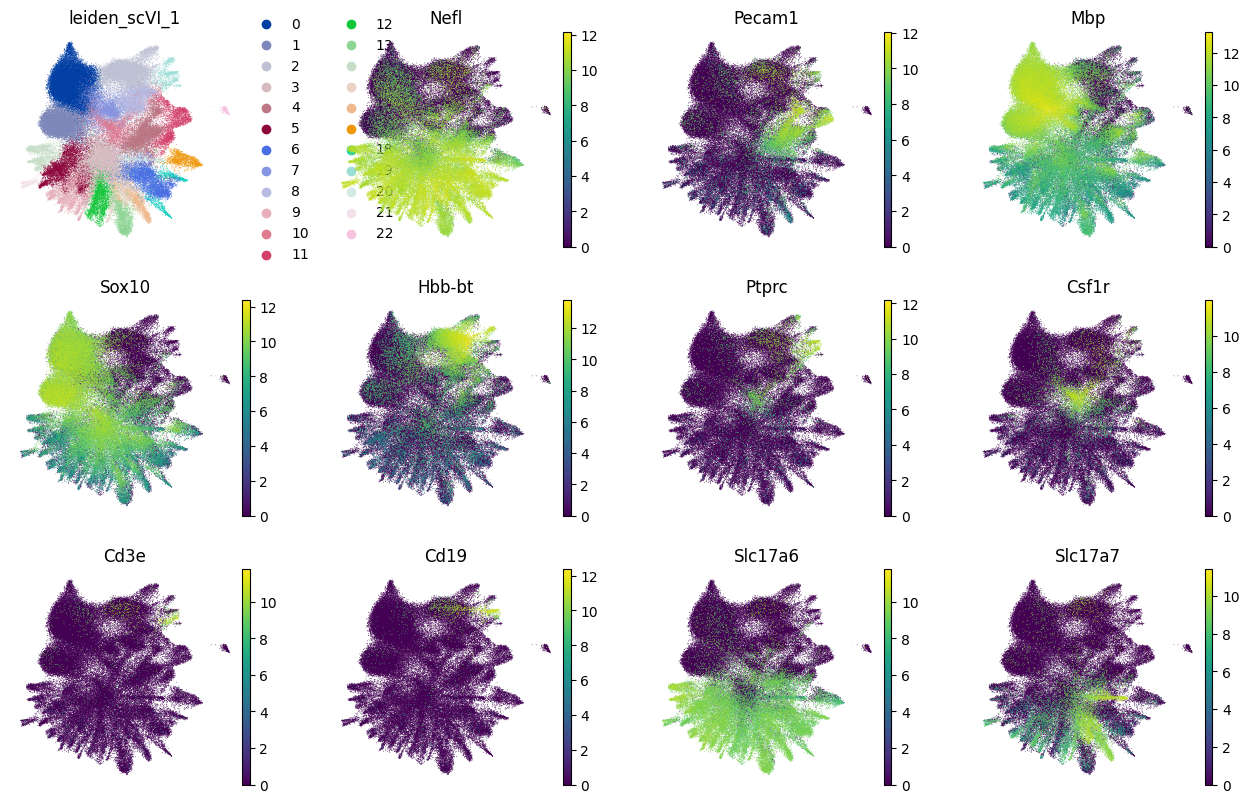

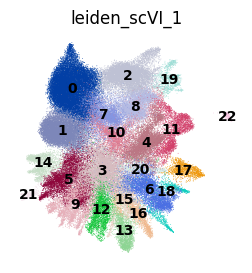

In [11]:
sc.pl.umap(adata, color = ['leiden_scVI_1', 'Nefl', 'Pecam1', 'Mbp', 'Sox10', 'Hbb-bt', 'Ptprc', 'Csf1r', 'Cd3e', 'Cd19', 'Slc17a6', 'Slc17a7'], frameon = False)
sc.pl.umap(adata, color = ['leiden_scVI_1'], frameon = False, legend_loc = 'on data')

# Assign `cell_type` annotation

In [12]:
cell_type = {str(i): "" for i in range(23)}
#cell_type

## L1: Cell class

In [13]:
cell_class = {'0': 'Glia',
 '1': 'Glia',
 '2': 'Immune-enriched',
 '3': 'Neuron',
 '4': 'Stromal',
 '5': 'Neuron',
 '6': 'Neuron',
 '7': 'Stromal',
 '8': 'Stromal',
 '9': 'Neuron',
 '10': 'Immune',
 '11': 'Stromal',
 '12': 'Neuron',
 '13': 'Neuron',
 '14': 'Neuron',
 '15': 'Neuron',
 '16': 'Neuron',
 '17': 'Neuron',
 '18': 'Neuron',
 '19': 'Immune',
 '20': 'Neuron',
 '21': 'Neuron',
 '22': 'Low-quality'}

adata.obs['cell_class'] = adata.obs['leiden_scVI_1'].map(cell_class)

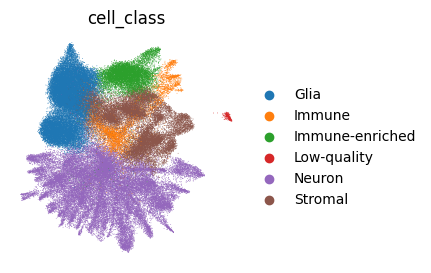

In [14]:
sc.pl.umap(adata, color = 'cell_class', frameon = False)

# Create neuronal subset

In [15]:
adata = adata[adata.obs['cell_class'] == 'Neuron'].copy()
adata

AnnData object with n_obs × n_vars = 37176 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nuclear_fraction', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'scvi_model', 'leiden_scVI_1', 'cell_class'
    var: 'Ensembl ID', 'Probesets', 'zhen_list', 'spectral_panel', 'neurons_supervised', 'neurons_unsupervised', 'glia_supervised', 'glia_unsupervised', 'other', 'neuron_DEGs', 'neuron_detection_rate', 'glia_detection_rate', 'combined_detection_rate_mean'
    uns: '_scvi_manager_uuid',

### Export

In [16]:
h5ad_path = os.path.join(output_dir, 'ModelB_whole_noTG_neurons.h5ad')
adata.write_h5ad(h5ad_path, compression='gzip')

print(h5ad_path)

/home/workspace/projects/drg/data/h5ad/export_03/01_broad-labels/ModelB_whole_noTG_neurons.h5ad


## Session info

In [17]:
print('active IDE: sc-charter')
print('active conda environment: ', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-charter
active conda environment:  sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


In [19]:
adata

AnnData object with n_obs × n_vars = 37176 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nuclear_fraction', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'scvi_model', 'leiden_scVI_1', 'cell_class'
    var: 'Ensembl ID', 'Probesets', 'zhen_list', 'spectral_panel', 'neurons_supervised', 'neurons_unsupervised', 'glia_supervised', 'glia_unsupervised', 'other', 'neuron_DEGs', 'neuron_detection_rate', 'glia_detection_rate', 'combined_detection_rate_mean'
    uns: '_scvi_manager_uuid',

In [22]:
adata.obs.cell_class.value_counts()

cell_class
Neuron    37176
Name: count, dtype: int64

In [21]:
dual_barcodes = [
    'bpoikicj-1-1', 'akcoadof-1-2', 'bgmdeeeb-1-2',
    'hjjgalia-1-2', 'bmjgagok-1-3', 'ijnggkoc-1-3'
]

# Keep only those that are actually present in adata
dual_in_a = [bc for bc in dual_barcodes if bc in adata.obs_names]

n_total = adata.n_obs
n_dual = len(dual_in_a)

percent = (n_dual / n_total) * 100

print(f"Dual-positive barcoded cells in adata: {n_dual} / {n_total} "
      f"({percent:.6f}%)")

Dual-positive barcoded cells in adata: 6 / 37176 (0.016139%)


## Session info

In [17]:
print('active IDE: sc-spatial-gpu')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial-gpu
active conda environment: sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
